<br>TUG Video
<br>   ↓
<br>COCO-17 (keypoints)
<br>   ↓
<br>Normalization + Filtering
<br>   ↓
<br>Signal Construction
<br>   ↓
<br>Sliding Window (2s)
<br>   ↓
<br>Feature Extraction (FI + others)
<br>   ↓
<br>FOG Detection Model
<br>   ↓
<br>FOG Statistics (per subject)
<br>   ↓
<br>PD vs Non-PD Classifier

In [1]:
import os
import json
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import savgol_filter, find_peaks
import matplotlib.pyplot as plt
import re

In [2]:
JSON_DIR = Path("D:/PD/PD_latest/dataset/alphapose_full")   
PROCESSED_DIR = Path("D:/PD/PD_latest/dataset/processed_cycles/fog/full")
CYCLES_DIR = PROCESSED_DIR / "cycles"
GROUPS_DIR = PROCESSED_DIR / "groups"
METADATA_PATH = PROCESSED_DIR / "metadata" / "cycle_metadata.csv"

CYCLES_DIR.mkdir(parents=True, exist_ok=True)
GROUPS_DIR.mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / "metadata").mkdir(parents=True, exist_ok=True)

DEFAULT_FPS = 30

# COCO keypoint indices
KEYPOINTS = {
    'nose': 0,
    'left_eye': 1, 'right_eye': 2,
    'left_ear': 3, 'right_ear': 4,
    'left_shoulder': 5, 'right_shoulder': 6,
    'left_elbow': 7, 'right_elbow': 8,
    'left_wrist': 9, 'right_wrist': 10,
    'left_hip': 11, 'right_hip': 12,
    'left_knee': 13, 'right_knee': 14,
    'left_ankle': 15, 'right_ankle': 16,
}

K = {name: i for i, name in enumerate(KEYPOINTS)}

COCO_EDGES = [
    (K['nose'], K['left_eye']), (K['left_eye'], K['left_ear']), 
    (K['nose'], K['right_eye']), (K['right_eye'], K['right_ear']),
    (K['left_shoulder'], K['left_elbow']), (K['left_elbow'], K['left_wrist']),
    (K['right_shoulder'], K['right_elbow']), (K['right_elbow'], K['right_wrist']),
    (K['left_shoulder'], K['right_shoulder']),
    (K['left_hip'], K['left_knee']), (K['left_knee'], K['left_ankle']),
    (K['right_hip'], K['right_knee']), (K['right_knee'], K['right_ankle']),
    (K['left_hip'], K['right_hip']),
    (K['left_shoulder'], K['left_hip']), (K['right_shoulder'], K['right_hip'])
]

In [3]:
def infer_label(file_id):
    fid_upper = file_id.upper()
    if 'PD' in fid_upper:
        return '1'
    elif 'NP' in fid_upper:
        return '0'
    else:
        return 'UNK'

def load_alphapose_json(json_path):
    """Load → (T, 34): [x0,y0,x1,y1,...,x16,y16]"""
    with open(json_path, 'r') as f:
        data = json.load(f)
    data_sorted = sorted(data, key=lambda x: x.get('image_id', x.get('idx', x.get('frame', 0))))
    frames = []
    for frame in data_sorted:
        kpts = np.array(frame['keypoints']).reshape(-1, 3)  # (17, 3)
        xy = kpts[:, :2].flatten()  # (34,)
        frames.append(xy)
    return np.array(frames)  # (T, 34)

def extract_gait_cycle(pose, joint_index=15, min_distance=20, smooth_window=9):
    """
    Detect gait cycles using y-coordinate of specified ankle (15=left, 16=right).
    Returns: cycles (list of arrays), peaks (int indices), y_smooth (for viz)
    """
    y_signal = pose[:, joint_index * 2 + 1]

    if len(y_signal) < 3 or np.all(np.isnan(y_signal)):
        return [], np.array([], dtype=int), y_signal

    # Safe Savitzky-Golay window
    max_win = len(y_signal) if len(y_signal) % 2 == 1 else len(y_signal) - 1
    win = min(smooth_window, max_win)
    if win < 3:
        win = 3
    if win % 2 == 0:
        win += 1

    try:
        y_smooth = savgol_filter(y_signal, win, polyorder=2)
    except Exception:
        y_smooth = y_signal.copy()

    prominence = max(1e-3, np.nanstd(y_smooth) * 0.2) if not np.all(np.isnan(y_smooth)) else 1e-3
    peaks, _ = find_peaks(y_smooth, distance=min_distance, prominence=prominence)
    peaks = np.array(peaks, dtype=int)

    # No fallback here — let caller handle joint switching
    if len(peaks) < 2:
        return [], peaks, y_smooth

    cycles = [pose[peaks[i]:peaks[i+1]] for i in range(len(peaks) - 1)]
    return cycles, peaks, y_smooth

def to_py(o):
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.integer, np.floating)):
        return o.item()
    if isinstance(o, list):
        return [to_py(x) for x in o]
    if isinstance(o, dict):
        return {k: to_py(v) for k, v in o.items()}
    return o

In [4]:
# =========================
# FOG FEATURE EXTRACTION
# =========================

def normalize_keypoints(xy_seq):
    """Normalize each frame into a fixed 80-unit box after 30% bbox expansion."""
    if xy_seq is None or len(xy_seq) == 0:
        return np.zeros((0, 34), dtype=np.float32)

    pts = np.asarray(xy_seq, dtype=np.float32).reshape(-1, 17, 2)
    norm_seq = []

    for frame in pts:
        x = frame[:, 0]
        y = frame[:, 1]

        xmin, xmax = np.nanmin(x), np.nanmax(x)
        ymin, ymax = np.nanmin(y), np.nanmax(y)

        width = xmax - xmin
        height = ymax - ymin

        if not np.isfinite(width) or width == 0:
            width = 1.0
        if not np.isfinite(height) or height == 0:
            height = 1.0

        xmin -= 0.15 * width
        xmax += 0.15 * width
        ymin -= 0.15 * height
        ymax += 0.15 * height

        denom = ymax - ymin
        if denom == 0:
            denom = 1.0
        scale = 80.0 / denom

        x_norm = (x - xmin) * scale
        y_norm = (y - ymin) * scale
        norm_seq.append(np.stack([x_norm, y_norm], axis=1))

    return np.array(norm_seq, dtype=np.float32).reshape(-1, 34)


def compute_motion_features(xy_seq, fps=30):
    """Return averaged ankle speed and speed-acceleration signals."""
    arr = np.asarray(xy_seq, dtype=np.float32)
    if arr.ndim != 2 or arr.shape[1] != 34:
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32)

    # left/right ankles
    xL = arr[:, 15 * 2]
    yL = arr[:, 15 * 2 + 1]
    xR = arr[:, 16 * 2]
    yR = arr[:, 16 * 2 + 1]

    vL = np.sqrt(np.diff(xL, prepend=xL[0]) ** 2 + np.diff(yL, prepend=yL[0]) ** 2) * fps
    vR = np.sqrt(np.diff(xR, prepend=xR[0]) ** 2 + np.diff(yR, prepend=yR[0]) ** 2) * fps
    speed = (vL + vR) / 2.0

    acc = np.diff(speed, prepend=speed[0]) * fps
    return speed.astype(np.float32), acc.astype(np.float32)


def sliding_window(signal, window_size=60, step=3):
    windows = []
    indices = []
    for i in range(0, len(signal) - window_size + 1, step):
        windows.append(signal[i:i + window_size])
        indices.append((i, i + window_size))
    return np.array(windows), indices


def compute_freezing_index(window, fs=30):
    freqs = np.fft.rfftfreq(len(window), d=1 / fs)
    fft_vals = np.abs(np.fft.rfft(window)) ** 2

    locomotor_band = (freqs >= 0.5) & (freqs < 3)
    freeze_band = (freqs >= 3) & (freqs <= 8)

    power_loco = np.sum(fft_vals[locomotor_band])
    power_freeze = np.sum(fft_vals[freeze_band])

    if power_loco == 0:
        return 0.0

    return float(power_freeze / power_loco)


def extract_window_features(signal, acc, fs=30, FI_threshold=2.0):
    """Extract per-window FOG feature vectors.

    Features per window:
    [mean_speed, std_speed, max_speed, min_speed, freezing_index, mean_acc]
    """
    windows, indices = sliding_window(signal, window_size=60, step=3)

    feature_seq = []
    FI_values = []
    fog_labels = []

    for i, w in enumerate(windows):
        st, en = indices[i]
        a = acc[st:en]

        mean_v = float(np.mean(w)) if len(w) else 0.0
        std_v = float(np.std(w)) if len(w) else 0.0
        max_v = float(np.max(w)) if len(w) else 0.0
        min_v = float(np.min(w)) if len(w) else 0.0

        FI = compute_freezing_index(w, fs=fs) if len(w) else 0.0
        mean_a = float(np.mean(a)) if len(a) else 0.0

        fog = 1 if FI > FI_threshold else 0

        feature_seq.append([mean_v, std_v, max_v, min_v, FI, mean_a])
        FI_values.append(FI)
        fog_labels.append(fog)

    return np.array(feature_seq, dtype=np.float32), np.array(FI_values, dtype=np.float32), np.array(fog_labels, dtype=np.int32), indices


def detect_fog(signal, fps=30, FI_threshold=2.0):
    """Compatibility wrapper used by earlier cells."""
    # If acceleration is not provided, estimate it from speed.
    acc = np.diff(signal, prepend=signal[0]) * fps if len(signal) else np.array([], dtype=np.float32)
    _, FI_values, fog_labels, indices = extract_window_features(signal, acc, fs=fps, FI_threshold=FI_threshold)
    return fog_labels, FI_values, indices


def remove_short_fog(fog_labels, min_duration=6):
    cleaned = fog_labels.copy()
    count = 0

    for i in range(len(fog_labels)):
        if fog_labels[i] == 1:
            count += 1
        else:
            if 0 < count < min_duration:
                cleaned[i - count:i] = 0
            count = 0

    # Handle trailing run of ones.
    if 0 < count < min_duration:
        cleaned[len(fog_labels) - count:len(fog_labels)] = 0

    return cleaned

In [5]:
# Backward-compatible helper used by earlier extraction cells
def compute_velocity_signal(xy_seq, joint_idx=15, fps=30):
    arr = np.asarray(xy_seq, dtype=np.float32)
    if arr.ndim != 2 or arr.shape[1] != 34 or len(arr) == 0:
        return np.array([], dtype=np.float32)

    x = arr[:, joint_idx * 2]
    y = arr[:, joint_idx * 2 + 1]

    vx = np.diff(x, prepend=x[0]) * fps
    vy = np.diff(y, prepend=y[0]) * fps
    return np.sqrt(vx ** 2 + vy ** 2).astype(np.float32)

In [6]:
metadata = []
json_files = sorted(JSON_DIR.glob("*.json"))
print(f"Found {len(json_files)} JSON files.")

for json_path in json_files:
    file_id = json_path.stem
    print(f"\n{file_id}")

    # 1. Load data
    try:
        xy_seq = load_alphapose_json(json_path)
        T = xy_seq.shape[0]
        print(f"  Loaded {T} frames")
        if T == 0:
            xy_seq = np.zeros((60, 34), dtype=np.float32)  # dummy sequence
            T = 60
    except Exception as e:
        print(f" Load error -> using dummy: {e}")
        xy_seq = np.zeros((60, 34), dtype=np.float32)
        T = 60

    # =========================
    # FOG DETECTION (NEW)
    # =========================
    try:
        # Use BOTH ankles (more robust)
        speed_L = compute_velocity_signal(xy_seq, joint_idx=15, fps=DEFAULT_FPS)
        speed_R = compute_velocity_signal(xy_seq, joint_idx=16, fps=DEFAULT_FPS)
        speed_signal = (speed_L + speed_R) / 2

        fog_labels, FI_values, win_indices = detect_fog(
            speed_signal, fps=DEFAULT_FPS, FI_threshold=2.0
        )

        # Remove short false positives
        fog_labels = remove_short_fog(fog_labels, min_duration=6)

        # Aggregate features
        fog_ratio = float(np.mean(fog_labels)) if len(fog_labels) > 0 else 0.0
        mean_fi = float(np.mean(FI_values)) if len(FI_values) > 0 else 0.0
        max_fi = float(np.max(FI_values)) if len(FI_values) > 0 else 0.0

        # Count FOG episodes
        fog_events = 0
        in_event = False
        for f in fog_labels:
            if f == 1 and not in_event:
                fog_events += 1
                in_event = True
            elif f == 0:
                in_event = False

    except Exception as e:
        print(f"  FOG extraction failed: {e}")
        fog_ratio, mean_fi, max_fi, fog_events = 0, 0, 0, 0
        fog_labels = np.array([], dtype=int)
        win_indices = []

    # Save FOG segments per subject inside the main loop for consistency.
    fog_segments = []
    for (start, end), label in zip(win_indices, fog_labels):
        if label == 1:
            fog_segments.append({
                "start_frame": int(start),
                "end_frame": int(end)
            })

    fog_out = {
        "file_id": file_id,
        "n_fog_segments": len(fog_segments),
        "segments": fog_segments
    }
    fog_path = PROCESSED_DIR / f"{file_id}_fog_segments.json"
    with open(fog_path, 'w', encoding='utf-8') as f:
        json.dump(fog_out, f, ensure_ascii=False, indent=2)

    # 2. Try gait cycle extraction (ankles -> knees -> fallback)
    cycles = []
    used_method = "fallback_uniform"
    peaks = np.array([], dtype=int)

    # Try ankles (15, 16)
    for joint_idx, name in [(15, "left_ankle"), (16, "right_ankle")]:
        try:
            c, p, _ = extract_gait_cycle(xy_seq, joint_index=joint_idx, min_distance=20)
            if len(c) >= 1:
                cycles = c
                peaks = p
                used_method = f"{name} ({len(c)} cycles)"
                break
        except Exception as e:
            print(f"    {name} failed: {e}")

    # Try knees if ankles failed
    if len(cycles) == 0:
        for joint_idx, name in [(13, "left_knee"), (14, "right_knee")]:
            try:
                c, p, _ = extract_gait_cycle(xy_seq, joint_index=joint_idx, min_distance=20)
                if len(c) >= 1:
                    cycles = c
                    peaks = p
                    used_method = f"{name} ({len(c)} cycles)"
                    break
            except Exception as e:
                print(f"    {name} failed: {e}")

    # uniform segmentation (guaranteed 6 cycles)
    if len(cycles) == 0:
        print(f" All joint-based detection failed -> using uniform segmentation")
        cycle_len = max(1, T // 6)
        cycles = []
        peaks = []
        for i in range(6):
            start = i * cycle_len
            end = min((i + 1) * cycle_len, T)
            if start >= T:
                break
            cyc = xy_seq[start:end]
            if len(cyc) == 0:
                cyc = xy_seq[-1:]  # repeat last frame
            cycles.append(cyc)
            peaks.append(start)
        peaks.append(T)  # final peak
        peaks = np.array(peaks[:7])  # ensure 7 peaks
        used_method = "uniform_segmentation"

    # At this point, cycles is non-empty (may be <6)
    detected = len(cycles)
    print(f"  -> Detected {detected} cycles ({used_method})")

    # 3. Enforce exactly 6 cycles
    original_cycle_count = detected
    if detected < 6:
        print(f"  Padding {6 - detected} cycles (repeating last valid cycle)")
        if detected == 0:
            # All else failed -> create 6 dummy cycles
            dummy_cycle = np.zeros((30, 34), dtype=np.float32)
            cycles = [dummy_cycle.copy() for _ in range(6)]
            peaks = np.linspace(0, 180, 7).astype(int)  # dummy peaks
        else:
            last_cycle = cycles[-1].copy()
            while len(cycles) < 6:
                cycles.append(last_cycle.copy())
    elif detected > 6:
        cycles = cycles[:6]
        peaks = peaks[:7] if len(peaks) >= 7 else np.linspace(0, T, 7).astype(int)

    # Ensure peaks has exactly 7 values
    if len(peaks) < 7:
        if original_cycle_count > 0 and 'peaks' in locals() and len(peaks) >= 2:
            avg_cycle_len = int(np.mean(np.diff(peaks)))
            while len(peaks) < 7:
                peaks = np.append(peaks, peaks[-1] + avg_cycle_len)
        else:
            peaks = np.linspace(0, T, 7).astype(int)
    peaks = peaks[:7]

    # 4. Save cycles & metadata (guaranteed 6)
    cycle_objs = []
    for i, cyc in enumerate(cycles[:6]):
        start_f = int(peaks[i])
        end_f = int(peaks[i + 1]) if i + 1 < len(peaks) else int(peaks[-1])
        is_padded = (i >= original_cycle_count)

        data = {
            'file_id': file_id,
            'cycle_id': i + 1,
            'start_frame': start_f,
            'end_frame': end_f,
            'n_frames_raw': len(cyc),
            'is_padded': is_padded,
            'xy': to_py(cyc)
        }
        cycle_objs.append(data)

        # Save JSON
        json_path_out = CYCLES_DIR / f"{file_id}_cycle_{i + 1}.json"
        with open(json_path_out, 'w', encoding='utf-8') as f:
            json.dump(to_py(data), f, ensure_ascii=False, indent=2)

        # Metadata
        metadata.append({
            'file_id': file_id,
            'cycle_id': i + 1,
            'start_frame': start_f,
            'end_frame': end_f,
            'n_frames_raw': len(cyc),
            'is_padded': is_padded,
            'detected_using': used_method,
            'original_cycle_count': original_cycle_count,
            'label': infer_label(file_id),
            'source': json_path.name,
            'fog_ratio': fog_ratio,
            'mean_fi': mean_fi,
            'max_fi': max_fi,
            'fog_events': fog_events
        })

    # Save grouped cycles (1 to 6) - PREFIX-BASED (1), (1+2), (1+2+3), ..., (1-6)
    def save_group(n, chunk):
        cids = [c['cycle_id'] for c in chunk]
        combined_xy = np.concatenate([np.asarray(c['xy']) for c in chunk], axis=0)
        out = {
            'file_id': file_id,
            'group_size': n,
            'cycle_ids': cids,
            'start_cycle': cids[0],
            'end_cycle': cids[-1],
            'n_frames_raw': len(combined_xy),
            'xy': to_py(combined_xy)
        }
        fname = f"{file_id}_{n}cycle_1-{n}.json"  # e.g., PD_01_3cycle_1-3.json
        with open(GROUPS_DIR / fname, 'w', encoding='utf-8') as f:
            json.dump(to_py(out), f, ensure_ascii=False, indent=2)

    # Generate cumulative groupings: 1-cycle, 1-2, 1-3, ..., 1-6
    for n in range(1, 7):
        chunk = cycle_objs[:n]  # First n cycles only
        save_group(n, chunk)

    print(f" Saved 6 cycles + {sum(6 // n for n in range(1, 7))} groups")

# Build metadata dataframe and save it for downstream cells
meta_df = pd.DataFrame(metadata)
meta_df.to_csv(METADATA_PATH, index=False)
print(f"\nSaved metadata: {METADATA_PATH} | shape={meta_df.shape}")

Found 40 JSON files.

NP_front_1
  Loaded 361 frames
  -> Detected 4 cycles (left_ankle (4 cycles))
  Padding 2 cycles (repeating last valid cycle)
 Saved 6 cycles + 14 groups

NP_front_12
  Loaded 206 frames
  -> Detected 6 cycles (left_ankle (6 cycles))
 Saved 6 cycles + 14 groups

NP_front_2
  Loaded 322 frames
  -> Detected 5 cycles (left_ankle (5 cycles))
  Padding 1 cycles (repeating last valid cycle)
 Saved 6 cycles + 14 groups

NP_front_6
  Loaded 226 frames
  -> Detected 3 cycles (left_ankle (3 cycles))
  Padding 3 cycles (repeating last valid cycle)
 Saved 6 cycles + 14 groups

NP_front_9
  Loaded 264 frames
  -> Detected 4 cycles (left_ankle (4 cycles))
  Padding 2 cycles (repeating last valid cycle)
 Saved 6 cycles + 14 groups

NP_old_1
  Loaded 462 frames
  -> Detected 9 cycles (left_ankle (9 cycles))
 Saved 6 cycles + 14 groups

NP_old_2
  Loaded 376 frames
  -> Detected 7 cycles (left_ankle (7 cycles))
 Saved 6 cycles + 14 groups

NP_old_4
  Loaded 402 frames
  -> Detect

In [7]:
# FOG segment JSON files are already saved per subject inside Cell 7 main loop.
# This cell provides a quick consistency check.

fog_segment_files = sorted(PROCESSED_DIR.glob("*_fog_segments.json"))
print(f"FOG segment files found: {len(fog_segment_files)}")

if fog_segment_files:
    with open(fog_segment_files[0], 'r', encoding='utf-8') as f:
        sample_fog = json.load(f)
    print("Example file:", fog_segment_files[0].name)
    print("file_id:", sample_fog.get("file_id"))
    print("n_fog_segments:", sample_fog.get("n_fog_segments"))
else:
    print("No FOG segment files found. Run Cell 7 first.")

FOG segment files found: 40
Example file: NP_front_12_fog_segments.json
file_id: NP_front_12
n_fog_segments: 23


In [8]:
meta_df.shape

(240, 14)

In [9]:
meta_df.head()

,file_id,cycle_id,start_frame,end_frame,n_frames_raw,is_padded,detected_using,original_cycle_count,label,source,fog_ratio,mean_fi,max_fi,fog_events
0,NP_front_1,1,61,94,33,False,left_ankle (4 cycles),4,0,NP_front_1.json,0.524752,2.055173,3.363591,3
1,NP_front_1,2,94,117,23,False,left_ankle (4 cycles),4,0,NP_front_1.json,0.524752,2.055173,3.363591,3
2,NP_front_1,3,117,139,22,False,left_ankle (4 cycles),4,0,NP_front_1.json,0.524752,2.055173,3.363591,3
3,NP_front_1,4,139,343,204,False,left_ankle (4 cycles),4,0,NP_front_1.json,0.524752,2.055173,3.363591,3
4,NP_front_1,5,343,413,204,True,left_ankle (4 cycles),4,0,NP_front_1.json,0.524752,2.055173,3.363591,3


# Visualization

In [10]:
video_path = "D:/PD/data/outputs/chosen_outputs/turn/NP/NP_front_1/NP_front_1.mp4"
json_path = "D:/PD/PD_latest/dataset/alphapose_turn/NP_front_1.json"

In [11]:
def plot_coco_skeleton(pose_flat, title=""):
    """
    Safely plot COCO-17 skeleton — with diagnostics.
    pose_flat: (34,) array: [x0,y0,x1,y1,...,x16,y16]
    """
    assert len(pose_flat) == 34, f"Expected 34 values, got {len(pose_flat)}"
    
    # Reshape safely
    kp = pose_flat.reshape(17, 2)  # (17, 2)
    
    # Replace NaN with np.nan (for skipping)
    kp = np.where(np.isfinite(kp), kp, np.nan)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Plot joints
    ax.scatter(kp[:, 0], kp[:, 1], c='red', s=100, zorder=5, edgecolors='white', linewidth=2)
    
    # Label joints (only if not NaN)
    for i in range(17):
        x, y = kp[i]
        if not np.isnan(x) and not np.isnan(y):
            ax.text(x + 3, y + 3, f"{i}", fontsize=8, fontweight='bold', zorder=6)
    
    # Draw limbs — skip if either joint is NaN
    for i1, i2 in COCO_EDGES:
        x1, y1 = kp[i1]
        x2, y2 = kp[i2]
        if not (np.isnan(x1) or np.isnan(y1) or np.isnan(x2) or np.isnan(y2)):
            ax.plot([x1, x2], [y1, y2], 'r-', linewidth=2.5, zorder=4)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    
    # AlphaPose outputs image coordinates → y increases downward → invert for plot
    ax.invert_yaxis()
    
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')
    plt.tight_layout()
    return fig, ax

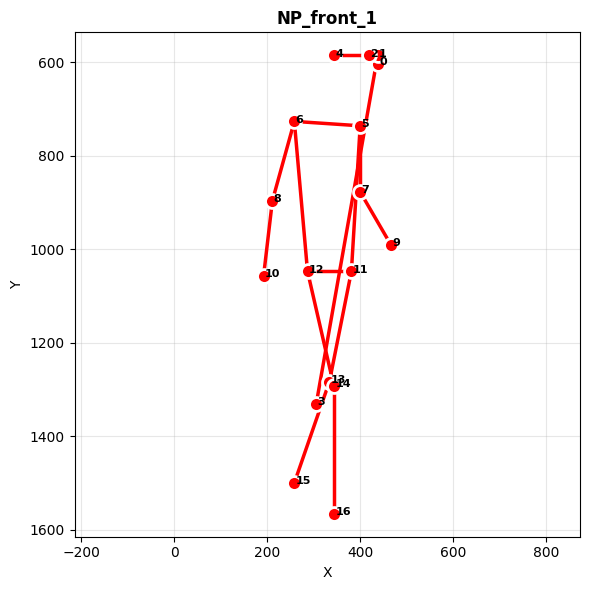

In [12]:
# Use json_path to find & visualize cycle 1's first frame
file_id = Path(json_path).stem
p = CYCLES_DIR / f"{file_id}_cycle_1.json"

# fallback: find first matching cycle file if exact one is missing
if not p.exists():
    matches = sorted(CYCLES_DIR.glob(f"{file_id}_cycle_*.json"))
    if matches:
        p = matches[0]

if not p.exists():
    raise FileNotFoundError(f"No cycle JSON found for {file_id} in {CYCLES_DIR}")

with open(p, 'r', encoding='utf-8') as f:
    obj = json.load(f)

# get xy array (support dict with 'xy' or bare list/array)
if isinstance(obj, dict) and 'xy' in obj:
    arr = np.array(obj['xy'])
else:
    arr = np.array(obj)

# ensure we pick a single 34-length frame
if arr.ndim == 1 and arr.size == 34:
    first_frame = arr
elif arr.ndim == 2 and arr.shape[1] == 34:
    first_frame = arr[0]
else:
    first_frame = arr.flatten()[:34]

# defensive cast and NaN handling
first_frame = np.asarray(first_frame, dtype=float)
first_frame[~np.isfinite(first_frame)] = np.nan

fig, ax = plot_coco_skeleton(first_frame, title=f"{file_id}")
plt.show()


Loaded 72 frames from JSON
   Frames available: [0, 1, 2, 3, 4]...


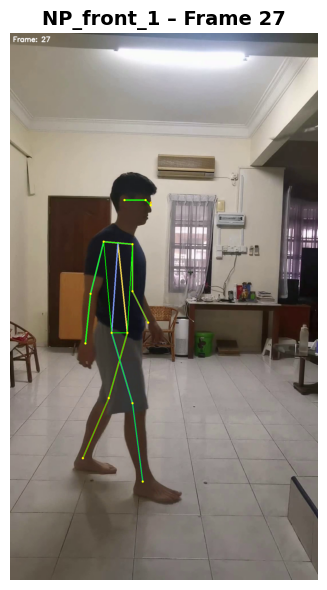

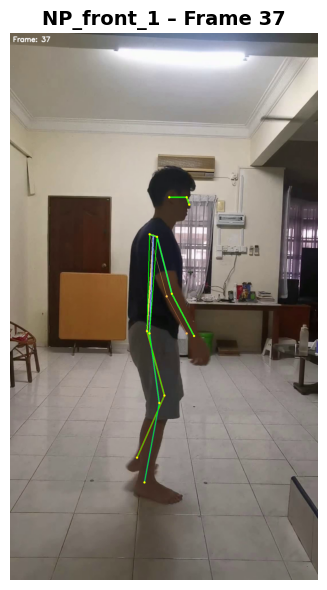

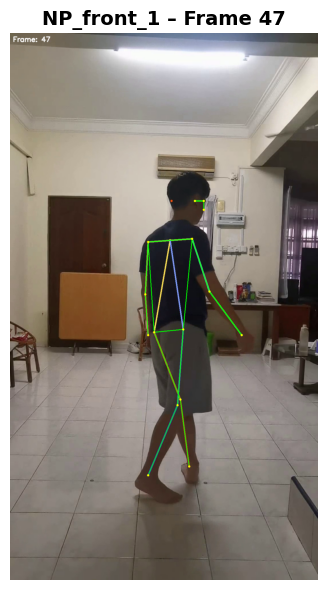

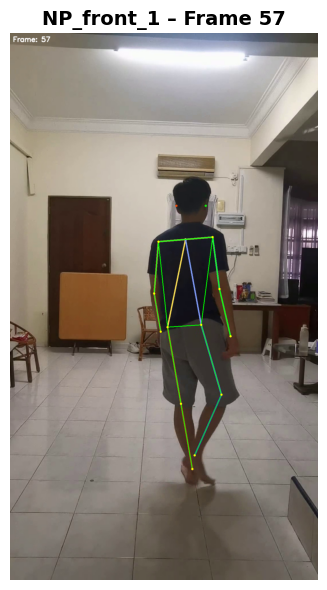

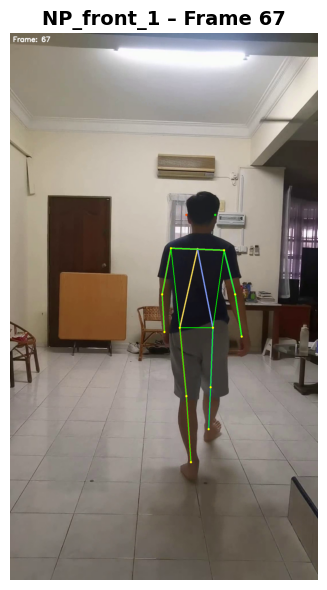

In [13]:
# peaks = np.array([27, 71, 115, 159, 203, 247, 291])  # example
peaks = None  # ← set to None or your array

start_frame = 27
end_frame = 71
step = 10  # frames to skip
confidence_thresh = 0.2  # min keypoint confidence

def parse_frame_number(image_id):
    """Robustly extract frame number from image_id string."""
    if isinstance(image_id, int):
        return image_id
    if not isinstance(image_id, str):
        return None
    # Remove extension
    stem = Path(image_id).stem
    # Find all numbers
    nums = re.findall(r'\d+', stem)
    if not nums:
        return None
    # Heuristic: last number is frame index (e.g., file_frameXYZ → XYZ)
    return int(nums[-1])
def load_keypoints_dict(json_path):
    """Load AlphaPose JSON → {frame_num: (17, 3) array}."""
    with open(json_path) as f:
        data = json.load(f)
    
    kp_dict = {}
    
    # Accept either a list of detections or a dict with 'annotations'
    if isinstance(data, list):
        items = data
    elif isinstance(data, dict) and 'annotations' in data and isinstance(data['annotations'], list):
        items = data['annotations']
    else:
        items = []
    
    for item in items:
        if not isinstance(item, dict):
            continue
        # support several possible keys for filename/id
        image_id = item.get('image_id') or item.get('image') or item.get('file_name')
        fid = parse_frame_number(image_id)
        if fid is None:
            continue
        kp_list = item.get('keypoints')
        if kp_list is None:
            continue
        try:
            kpts = np.array(kp_list).reshape(-1, 3)
            # ensure we have at least 17 keypoints; trim extras
            if kpts.ndim == 2 and kpts.shape[1] == 3 and kpts.shape[0] >= 17:
                kpts = kpts[:17, :]
                kp_dict[fid] = kpts
        except Exception:
            continue
    return kp_dict

def draw_skeleton(frame, keypoints, edges, 
                  joint_color=(0, 255, 255), limb_color=(0, 255, 0),
                  thickness=2, radius=4, conf_thresh=0.2):
    """Draw COCO skeleton on OpenCV BGR frame."""
    h, w = frame.shape[:2]
    # Draw limbs
    for i1, i2 in edges:
        x1, y1, s1 = keypoints[i1]
        x2, y2, s2 = keypoints[i2]
        if s1 >= conf_thresh and s2 >= conf_thresh:
            pt1 = (int(np.clip(x1, 0, w-1)), int(np.clip(y1, 0, h-1)))
            pt2 = (int(np.clip(x2, 0, w-1)), int(np.clip(y2, 0, h-1)))
            cv2.line(frame, pt1, pt2, limb_color, thickness)
            cv2.circle(frame, pt1, radius, joint_color, -1)
            cv2.circle(frame, pt2, radius, joint_color, -1)
    return frame

def annotate_frame(frame, frame_idx, is_peak=False):
    """Add frame number and optional peak marker."""
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(frame, f"Frame: {frame_idx}", (10, 30), 
                font, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
    if is_peak:
        cv2.putText(frame, "PEAK", (10, 60), font, 0.8, (0, 0, 255), 2, cv2.LINE_AA)
        cv2.rectangle(frame, (5, 5), (frame.shape[1]-5, frame.shape[0]-5), (0, 0, 255), 3)
    return frame

# ──────────────── MAIN ────────────────

# Load data
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {video_path}")

kp_dict = load_keypoints_dict(json_path)
if not kp_dict:
    raise ValueError("No keypoints loaded from JSON")

print(f"Loaded {len(kp_dict)} frames from JSON")
print(f"   Frames available: {sorted(kp_dict.keys())[:5]}...")

# Set frame range
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if end_frame is None:
    end_frame = total_frames - 1
frame_range = range(start_frame, min(end_frame + 1, total_frames), step)

# Plot frames
for fid in frame_range:
    # Read frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
    ret, frame = cap.read()
    if not ret:
        print(f"Failed to read frame {fid}")
        continue
    
    # Get keypoints (fallback: nearest frame if missing)
    if fid in kp_dict:
        kpts = kp_dict[fid]
    else:
        # Find nearest available frame
        available = np.array(list(kp_dict.keys()))
        if len(available) == 0:
            print(f"No keypoints for any frame")
            continue
        nearest = available[np.argmin(np.abs(available - fid))]
        kpts = kp_dict[nearest]
        print(f"Frame {fid} missing → using nearest: {nearest}")
    
    # Draw skeleton
    frame_vis = draw_skeleton(
        frame.copy(), 
        kpts, 
        COCO_EDGES,
        conf_thresh=confidence_thresh
    )
    
    # Annotate
    is_peak = peaks is not None and fid in peaks
    frame_vis = annotate_frame(frame_vis, fid, is_peak=is_peak)
    
    # Convert BGR → RGB for matplotlib
    rgb = cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.imshow(rgb)
    plt.title(f"{Path(video_path).stem} – Frame {fid}", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

cap.release()